# SunSim tutorial

This notebook simulates a star with spots and faculae and computes three kinds of observables.

| Section | What is computed | `mode` of `StarSim` |
|---|---|---|
| 3 | Light curve from **low resolution** spectra: one spot, one facula, and several regions (a facula around a spot, the same but re-centred, several latitudes) | `'photometry'` |
| 4 | **Low resolution** spectra during a facula transit, without rotation | `'spectroscopy'` |
| 5 | The same with **high resolution** spectra | `'spectroscopy'` |
| 6 | Disk-integrated quiet photosphere with and without rotation (solar inclination) | `flux_grid` only |
| 7 | **RV, BIS and FWHM** from the CCF, for the same transits as in the photometry | `'ccf'` |

## 1. How the simulation works

**The stellar disc.** The visible disc is cut in `N_rings` concentric rings of equal width, and every ring in cells of similar area (about 2(2N−1)²/π cells in total: 230 for N = 10, 9014 for N = 60). All the cells of a ring have the same projected angle μ (μ = 1 at the disc centre, μ → 0 at the limb), so they share the same limb darkening.

**Three kinds of surface.** The quiet photosphere, the spots and the faculae. For each one you provide the specific intensity spectrum at several values of μ, as a dictionary `{mu: {'wav': wavelengths [A], 'intensity': intensity}}`.

**Grids.** A grid stores, for every cell, the signal that the cell would give if it were entirely quiet, entirely spot or entirely facula:

* `flux_grid` gives one number per cell (`mode='photometry'`) or one spectrum per cell (`mode='spectroscopy'`). With `stellar_rotation=True` the spectrum of every cell is Doppler shifted by the rotation velocity of the cell.
* `CCF_grid` gives the CCF of every ring (section 7).

**Active regions.** `active_region(typ, size, latitude, longitude)` is a circular spot (`'sp'`) or facula (`'fc'`):

| argument | meaning |
|---|---|
| `typ` | `'sp'` spot, `'fc'` facula |
| `size` | angular radius [deg] |
| `latitude` | despite its name it is the **colatitude** [deg]: 90 = equator, 60 = latitude +30°, 120 = latitude −30° |
| `longitude` | [deg] at t = 0. The star rotates with `rotation_period`: longitude 180° is on the far side at t = 0 and crosses the disc centre at t = P/2 |

Spots and faculae are independent objects (any position, any size). Where they overlap, the spot is on top of the facula. `appearance_time` and `lifetime` are not applied yet: the regions are always present, with a constant size.

**StarSim.** At every epoch it computes the position of the regions and, for every cell, the fraction covered by the spot, the facula (and the planet): the *filling factors* `ff`. The signal is then the sum over the cells

`signal = Σ_cells [ ff_quiet · signal_quiet + ff_spot · signal_spot + ff_facula · signal_facula ]`

where the three filling factors of a cell add up to one. `mode` is a list with any of `'photometry'`, `'spectroscopy'` and `'ccf'`; the geometry is computed once per epoch for all of them. The results are `flux_var` (photometry), `spec_var` (spectroscopy), `ccf_var` and its parameters `rv_var`, `fwhm_var`, `bis_var`, `contrast_var` (ccf), and the filling factors `ff_sp`, `ff_fc` [% of the disc].

**Inclination.** `inclination` [rad] is the angle between the rotation axis and the plane of the sky: 0 is equator-on (the axis is perpendicular to the line of sight, used for the transits below) and π/2 is pole-on. The Sun is seen almost equator-on: its axis is tilted by at most 7.25° (section 6).

## 2. Setup: parameters and spectra

The quiet photosphere and the faculae come from the MPS-ATLAS spectra files. The spot spectrum is built from the `av_solar_ssd_10_mu_angles` spectra, multiplied by the ratio of black bodies at `T_quiet − spot_dT` and at `T_quiet`. The low resolution spectra are used for the photometry and for the low resolution spectroscopy, the high resolution ones for the high resolution spectroscopy and for the CCF.

In [20]:
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt

from main import *
from flux_grid import *
from ccf_grid import *
from active_region import *
from spectrum_utils import *        # black_body, mask_weights, ...

In [21]:
##### Star #####
rotation_period = 24.47            # [days]
stellar_radius = 1                 # [solar radii]
inclination = 0                    # [rad] equator-on, used for the transits (see section 1)
differential_rotation = 0
T_quiet = 5770                     # [K]
spot_dT = 500                      # [K] the spot is cooler than the quiet photosphere by this amount

##### Epochs: one rotation #####
n_times = 60
time = np.linspace(0, rotation_period, n_times)      # [days]

##### Spectra {mu: {'wav': ..., 'intensity': ...}}: quiet photosphere, facula, spot; high and low resolution #####
flux_quiet = np.load('/Users/sophiestucki/Library/CloudStorage/GoogleDrive-stucki@ieec.cat/Shared drives/Exoplanets-Group/MPS-ATLAS spectra/av_solar_ssd_200G_10_mu_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_quiet_low = np.load('/Users/sophiestucki/Documents/poet/mps/av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy', allow_pickle=True).item()

flux_fc = np.load('/Users/sophiestucki/Library/CloudStorage/GoogleDrive-stucki@ieec.cat/Shared drives/Exoplanets-Group/MPS-ATLAS spectra/av_solar_faculae_200G_10_mu_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_fc_low = np.load('/Users/sophiestucki/Documents/poet/mps/av_solar_faculae_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy', allow_pickle=True).item()

flux_sp = np.load('/Users/sophiestucki/Downloads/vxdrift_corrected_ssd_spectra/av_solar_ssd_10_mu_angles_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_sp_low = np.load('/Users/sophiestucki/Downloads/vxdrift_corrected_ssd_spectra/av_solar_ssd_10_mu_angles_PHOENIX_low_res_specint_grid.npy', allow_pickle=True).item()

for mu in flux_sp.keys():
    # the spot is cooler: black-body ratio
    flux_sp[mu]['intensity'] *= black_body(flux_sp[mu]['wav'], (T_quiet-spot_dT)) / black_body(flux_sp[mu]['wav'], T_quiet)
    flux_sp_low[mu]['intensity'] *= black_body(flux_sp_low[mu]['wav'], (T_quiet-spot_dT)) / black_body(flux_sp_low[mu]['wav'], T_quiet)
    # unit conversion of the low resolution spectra (kept from the previous version of the notebook)
    flux_sp_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10) / 1e12
    flux_quiet_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10)/ 1e12
    flux_fc_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10)/ 1e12

print('mu of the spectra:', sorted(flux_quiet.keys()))

mu of the spectra: ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']


In [22]:
def cut_spectra(flux, lo, hi):
    """Keep only the wavelengths between lo and hi [A] of a {mu: {'wav', 'intensity'}} dictionary."""
    out = {}
    for mu, d in flux.items():
        keep = (d['wav'] >= lo) & (d['wav'] <= hi)
        out[mu] = {'wav': d['wav'][keep], 'intensity': d['intensity'][keep]}
    return out


def simulate(regions, mode, N_rings, **grids):
    """StarSim for a list of active regions, with the star seen equator-on. grids: flux_grid_qp / _sp / _fc or ccf_grid_qp / _sp / _fc."""
    ss = StarSim(time, N_rings, inclination=inclination, rotation_period=rotation_period,
                 differential_rotation=differential_rotation, active_regions_map=regions,
                 mode=mode, stellar_radius=stellar_radius, **grids)
    with contextlib.redirect_stdout(io.StringIO()):      # StarSim prints its progress, not needed here
        ss.generate_timeseries()
    return ss

## 3. Photometry with low resolution spectra

**Idea.** For photometry only the integrated flux matters, so low resolution spectra are enough. `flux_grid(..., mode='photometry')` interpolates the spectrum at the μ of every ring, integrates it over the wavelength range of the filter (here a box between 3800 and 8000 Å, because `filter_path=None`), and multiplies it by the projected area of the cell. The result is one number per cell (`grid`). `total_brightness` is the sum over the cells, the flux of the quiet star.

Three grids are needed: quiet photosphere, facula and spot. Photometry is cheap, so we use 60 rings (about 9000 cells).

At every epoch `StarSim` then computes `flux = Σ_cells ff_quiet·F_quiet + ff_sp·F_spot + ff_fc·F_facula` (`flux_var`). We plot it as `ΔF/F` with respect to the quiet star.

In [23]:
N_rings_phot = 60

def photometry_grid(flux_low, typ):
    g = flux_grid(N_rings_phot, flux_low, typ, None, 3800, 8000, rotation_period=rotation_period, inclination=inclination,
                  stellar_radius=stellar_radius, stellar_rotation=False, mode='photometry')
    g.built_grid()
    return g

flux_grid_quiet = photometry_grid(flux_quiet_low, 'quiet')
flux_grid_fc = photometry_grid(flux_fc_low, 'fc')
flux_grid_sp = photometry_grid(flux_sp_low, 'sp')

### The active regions

Five cases are simulated. All the regions cross the disc during the rotation (the centre of the longitude-180° regions transits at t = P/2), and none is visible at t = 0.

| case | regions |
|---|---|
| `spot` | one spot, radius 10°, on the equator, longitude 180° |
| `facula` | one facula at the same position |
| `facula around a spot` | spot of radius 8° and facula of radius 14° with the same centre: the facula is a ring around the spot |
| `recentred facula` | the same, but the centre of the facula is displaced by 10° in longitude: the spot now sticks out of the facula on one side, so the facula only partly surrounds it (with a displacement smaller than 6° = 14° − 8° the spot would stay inside the facula, off-centre) |
| `several latitudes` | three spot + facula pairs (radius 7° and 12°) at colatitude 60°, 90° and 120° (latitude +30°, 0°, −30°) and longitude 165°, 180° and 195° |

Where the spot is on top of the facula the visible part of the facula is the facula minus the spot. When they only partly overlap, the part of a cell that is covered by the facula and not by the spot is approximated as `facula × (1 − spot)`.

In [24]:
several = []
for colatitude, longitude in [(60, 165), (90, 180), (120, 195)]:
    several += [active_region('sp', 7, colatitude, longitude), active_region('fc', 12, colatitude, longitude)]

scenarios = {
    'spot':                 [active_region('sp', 10, 90, 180)],
    'facula':               [active_region('fc', 10, 90, 180)],
    'facula around a spot': [active_region('sp', 8, 90, 180), active_region('fc', 14, 90, 180)],
    'recentred facula':     [active_region('sp', 8, 90, 180), active_region('fc', 14, 90, 190)],
    'several latitudes':    several,
}

In [25]:
photometry = {}
for name, regions in scenarios.items():
    photometry[name] = simulate(regions, ['photometry'], N_rings_phot,
                                flux_grid_qp=flux_grid_quiet.grid, flux_grid_sp=flux_grid_sp.grid, flux_grid_fc=flux_grid_fc.grid)

def relative_flux(ss):
    """Delta F / F with respect to the quiet star [%]."""
    return 100 * (ss.flux_var / flux_grid_quiet.total_brightness - 1)

**One spot and one facula.** The spot only darkens the star: a dip, deepest when the spot is at the disc centre, where it is least foreshortened. The facula is brighter than the photosphere, and increasingly so towards the limb: it brightens the star most when it is close to the limb, and less at the disc centre (two maxima and a dip in between).

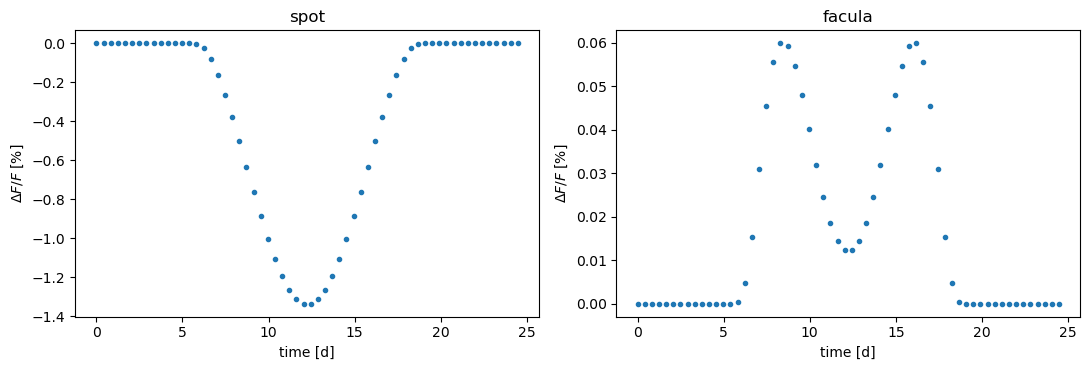

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, name in zip(axes, ['spot', 'facula']):
    ax.plot(photometry[name].obs_times, relative_flux(photometry[name]), '.')
    ax.set_title(name)
    ax.set_xlabel('time [d]')
    ax.set_ylabel('$\\Delta F / F$ [%]')
plt.tight_layout()
plt.show()

**Several regions.** Top: the light curve. Bottom: the fraction of the disc covered by the spots (`ff_sp`) and by the visible part of the faculae (`ff_fc`), in %. The spot is on top of the facula, so the facula only counts where it is not covered by the spot. The curve is therefore not the sum of the single-region curves: the spot hides the part of the facula that is below it.

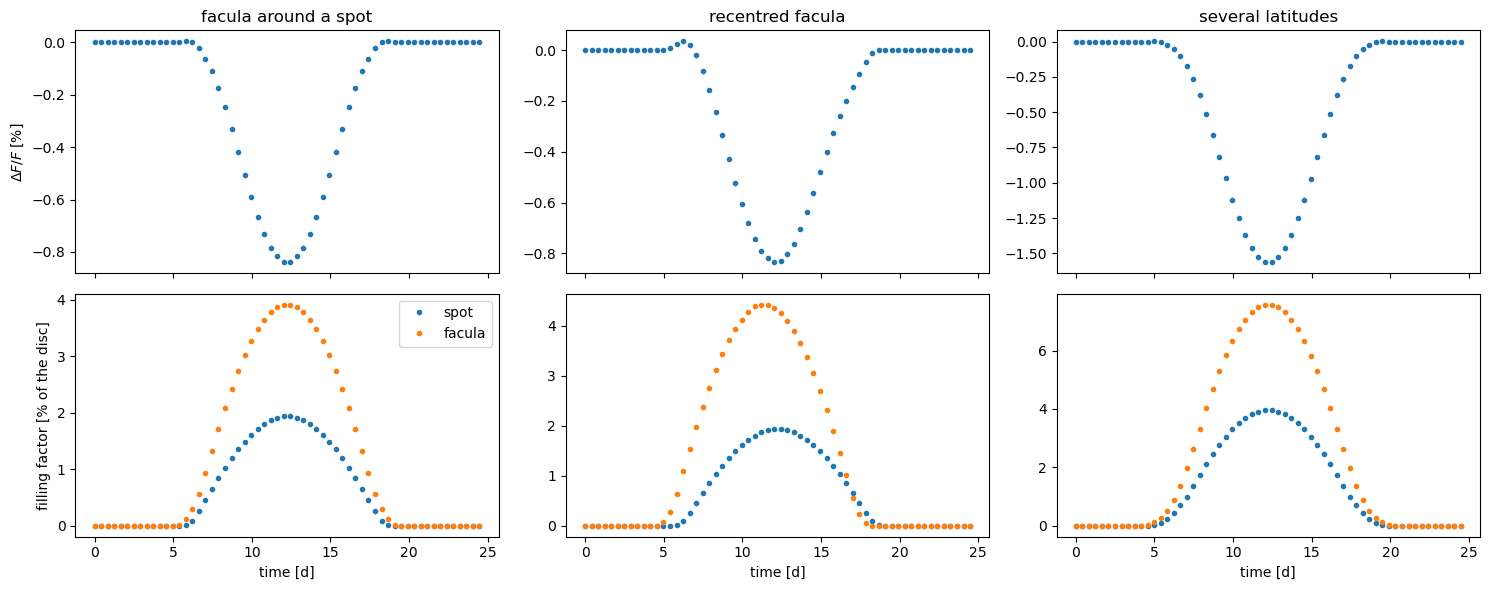

In [27]:
multi = ['facula around a spot', 'recentred facula', 'several latitudes']
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
for j, name in enumerate(multi):
    ss = photometry[name]
    axes[0, j].plot(ss.obs_times, relative_flux(ss), '.')
    axes[0, j].set_title(name)
    axes[1, j].plot(ss.obs_times, ss.ff_sp, '.', label='spot')
    axes[1, j].plot(ss.obs_times, ss.ff_fc, '.', label='facula')
    axes[1, j].set_xlabel('time [d]')
axes[0, 0].set_ylabel('$\\Delta F / F$ [%]')
axes[1, 0].set_ylabel('filling factor [% of the disc]')
axes[1, 0].legend()
plt.tight_layout()
plt.show()

## 4. Low resolution spectroscopy: a facula transit (no rotation)

`flux_grid(..., mode='spectroscopy')` keeps the whole spectrum of every cell instead of integrating it: `grid` has the shape `(n_cells, n_wavelengths)`. With `stellar_rotation=False` all the cells of a ring have the same spectrum (no Doppler shift). `StarSim(mode=['spectroscopy'])` then returns `spec_var`, an array `(n_times, n_wavelengths)` with the disk-integrated spectrum at every epoch.

The grids are much bigger than in photometry, so we use 20 rings (about 1000 cells). We simulate the facula of section 3 and plot, for a few epochs, the spectrum and its relative difference with the spectrum at t = 0, when the facula is on the far side and the star is the quiet one.

In [28]:
N_rings_spec = 20

def spectroscopy_grid(flux, typ, lo, hi):
    """Spectrum of every cell between lo and hi [A], without rotation."""
    g = flux_grid(N_rings_spec, flux, typ, None, lo, hi, rotation_period=rotation_period, inclination=inclination,
                  stellar_radius=stellar_radius, stellar_rotation=False, mode='spectroscopy')
    g.built_grid()
    return g

spec_grid_quiet = spectroscopy_grid(flux_quiet_low, 'quiet', 3800, 8000)
spec_grid_fc = spectroscopy_grid(flux_fc_low, 'fc', 3800, 8000)
spec_grid_sp = spectroscopy_grid(flux_sp_low, 'sp', 3800, 8000)

facula_low = simulate(scenarios['facula'], ['spectroscopy'], N_rings_spec,
                      flux_grid_qp=spec_grid_quiet.grid, flux_grid_sp=spec_grid_sp.grid, flux_grid_fc=spec_grid_fc.grid)
print('spec_var:', facula_low.spec_var.shape, '(n_times, n_wavelengths)')

spec_var: (60, 4199) (n_times, n_wavelengths)


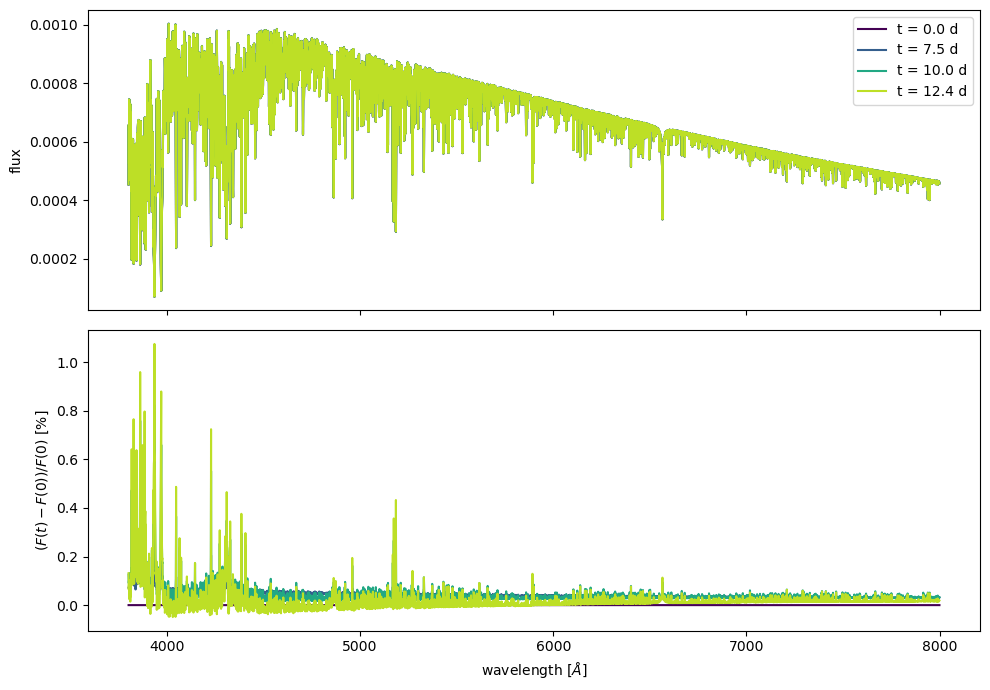

In [29]:
def plot_spectra_and_differences(wv, spec, fractions=(0.0, 0.30, 0.40, 0.50), xlim=None):
    """Spectra at some epochs (given as fractions of the rotation period) and their relative difference with the spectrum at time = 0."""
    idx = [int(np.argmin(np.abs(time - f * rotation_period))) for f in fractions]
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(idx)))
    shown = np.ones(len(wv), dtype=bool) if xlim is None else (wv >= xlim[0]) & (wv <= xlim[1])    # only these wavelengths are plotted
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        for k, color in zip(idx, colors):
            label = 't = %.1f d' % time[k]
            ax1.plot(wv[shown], spec[k][shown], color=color, label=label)
            ax2.plot(wv[shown], 100 * (spec[k][shown] / spec[0][shown] - 1), color=color, label=label)
    ax1.set_ylabel('flux')
    ax2.set_ylabel('$(F(t) - F(0)) / F(0)$ [%]')
    ax2.set_xlabel('wavelength [$\\AA$]')
    ax1.legend()
    if xlim is not None:
        ax1.set_xlim(xlim)
    plt.tight_layout()
    plt.show()

plot_spectra_and_differences(spec_grid_quiet.wv, facula_low.spec_var)

## 5. High resolution spectroscopy: a facula transit (no rotation)

The same with the high resolution spectra. A high resolution spectrum has hundreds of thousands of wavelengths, and `grid` stores one spectrum per cell, so we keep only a small wavelength window (`cut_spectra`) and use 20 rings. The spectra are plotted in a zoom of the window where individual lines can be seen.

In [30]:
N_rings_hr = 20
wl_window = (5000.0, 5004.0)         # [A] part of the spectrum that is simulated
zoom = (5000.25, 5001.2)             # [A] part that is plotted

hr_quiet = cut_spectra(flux_quiet, *wl_window)
hr_fc = cut_spectra(flux_fc, *wl_window)
hr_sp = cut_spectra(flux_sp, *wl_window)

def hr_spectroscopy_grid(flux, typ, stellar_rotation=False, incl=inclination):
    g = flux_grid(N_rings_hr, flux, typ, None, *wl_window, rotation_period=rotation_period, inclination=incl,
                  stellar_radius=stellar_radius, stellar_rotation=stellar_rotation, mode='spectroscopy')
    g.built_grid()
    return g

hr_grid_quiet = hr_spectroscopy_grid(hr_quiet, 'quiet')
hr_grid_fc = hr_spectroscopy_grid(hr_fc, 'fc')
hr_grid_sp = hr_spectroscopy_grid(hr_sp, 'sp')

facula_high = simulate(scenarios['facula'], ['spectroscopy'], N_rings_hr,
                       flux_grid_qp=hr_grid_quiet.grid, flux_grid_sp=hr_grid_sp.grid, flux_grid_fc=hr_grid_fc.grid)
print('spec_var:', facula_high.spec_var.shape, '(n_times, n_wavelengths)')

spec_var: (60, 401) (n_times, n_wavelengths)


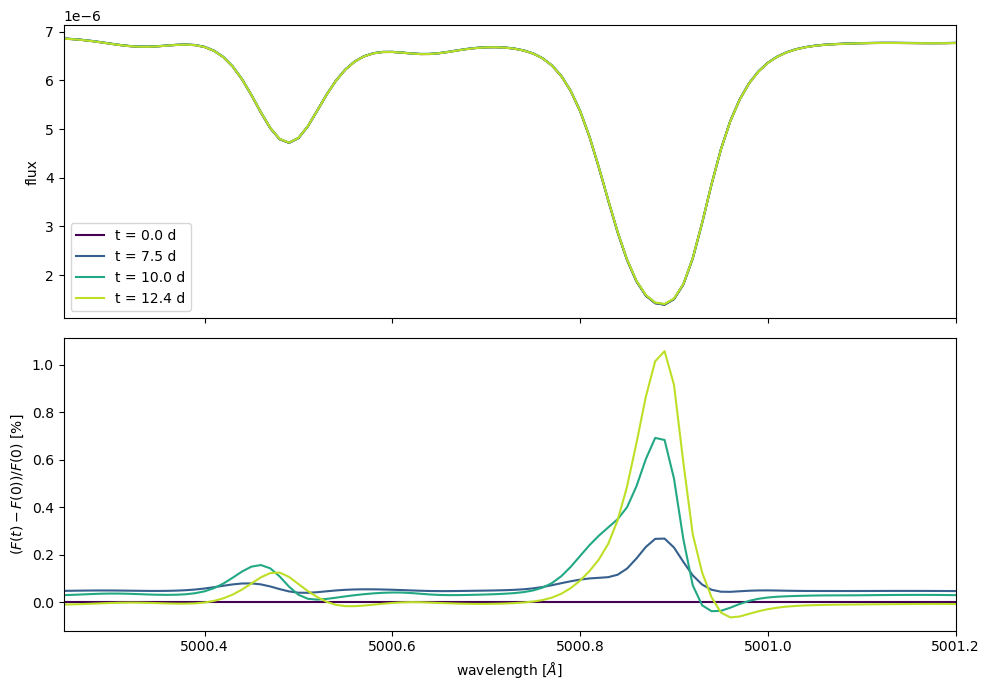

In [31]:
plot_spectra_and_differences(hr_grid_quiet.wv, facula_high.spec_var, xlim=zoom)

## 6. Disk-integrated quiet photosphere, with and without rotation

`flux_grid(..., stellar_rotation=True)` Doppler shifts the spectrum of every cell by the rotation velocity of the cell (`vsini`, the projected equatorial velocity 2πR cos(i) / P with i the inclination defined above, times a factor that depends on the position of the cell), so the disk-integrated spectrum is the sum over the cells of spectra shifted towards the blue on the approaching side and towards the red on the receding side: the lines are broadened. We use the solar inclination, a rotation axis tilted by 7.25° with respect to the plane of the sky, and compare with the spectrum of the same star at rest.

In [32]:
inclination_sun = np.deg2rad(7.25)       # [rad]

grid_rest = hr_spectroscopy_grid(hr_quiet, 'quiet', stellar_rotation=False, incl=inclination_sun)
grid_rot = hr_spectroscopy_grid(hr_quiet, 'quiet', stellar_rotation=True, incl=inclination_sun)

disk_rest = grid_rest.grid.sum(axis=0)       # disk-integrated spectra
disk_rot = grid_rot.grid.sum(axis=0)
print('vsini = %.2f km/s' % (grid_rot.vsini / 1000))

vsini = 2.05 km/s


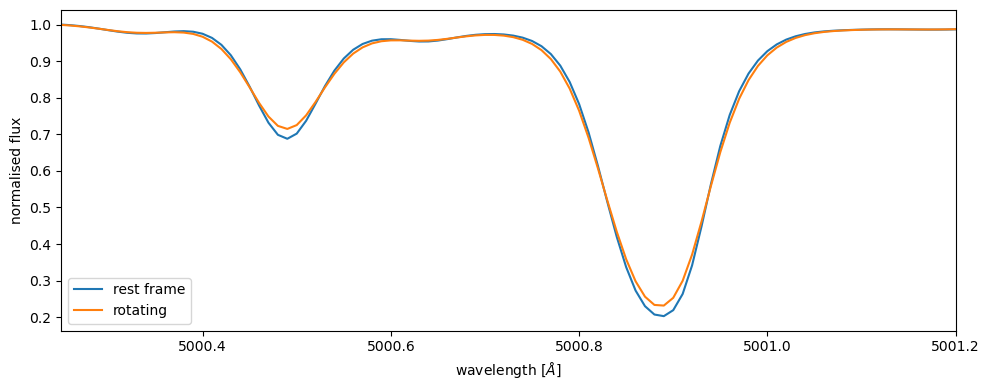

In [33]:
in_rest = (grid_rest.wv >= zoom[0]) & (grid_rest.wv <= zoom[1])      # only the zoom is plotted
in_rot = (grid_rot.wv >= zoom[0]) & (grid_rot.wv <= zoom[1])
norm = disk_rest[in_rest].max()                                       # same normalisation for both spectra

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grid_rest.wv[in_rest], disk_rest[in_rest] / norm, label='rest frame')
ax.plot(grid_rot.wv[in_rot], disk_rot[in_rot] / norm, label='rotating')
ax.set_xlim(zoom)
ax.set_ylabel('normalised flux')
ax.set_xlabel('wavelength [$\\AA$]')
ax.legend()
plt.tight_layout()
plt.show()

## 7. CCF mode: RV, BIS and FWHM

**Idea.** The CCF is the cross-correlation of the spectrum with a mask of lines (here `HARPS_G20_mps_friendly.mas`). `CCF_grid` computes the CCF of the rings. `StarSim(mode=['ccf'])` places the CCF of every ring on the velocity axis, shifted by the rotation velocity of each cell (Doppler shift), and sums over the cells with the filling factors:

`ccf(t) = Σ_cells [ ff_quiet · ccf_quiet + ff_sp · ccf_spot + ff_fc · ccf_facula ]`

Finally `compute_ccf_params` fits a gaussian to every CCF (`rv_var`, `fwhm_var`, `contrast_var`) and computes the bisector span (`bis_var`: mean velocity of the bisector at 10-40 % of the CCF height minus the mean at 60-90 %). All of them are in m/s, except the contrast.

**`CCF_grid` has two steps.** `compute_ccf()` gives the CCF of the rings, `rv_treatment()` the velocity axis on which they are placed, and `built_grid()` runs both.

**Why `mu_ratio`.** The CCF of a ring is normalised to the continuum of its own spectrum, so by itself it does not know that the ring is darker than the disc centre (limb darkening), or that a spot is darker than the photosphere. Without that, a spot would hardly unbalance the rotation of the star and the RV would barely change. With `mu_ratio` the CCF of a ring is multiplied by the brightness of the ring relative to the quiet disc centre. We take these brightness ratios from the low resolution flux grids (same limb darkening, same spot and facula contrast as in the photometry), in the wavelength range of the mask.

**Spectra of the rings.** The high resolution spectra at the 10 μ angles are given to `CCF_grid`: the spectrum of every ring is interpolated between them (and extrapolated towards the limb below μ = 0.1), and its CCF is computed. Every ring therefore keeps the line shape of its own spectrum, and in particular its bisector: the convective blueshift of the quiet photosphere and its reduction in the faculae, and their variation with μ.

**RV treatment.** No bisector is removed: the CCF of every ring is placed at the velocity given by its own spectrum. On top of that a bisector can be added, multiplied by `convective_blueshift`; here `convective_blueshift = 0` for the three surfaces, so nothing is added and the RV changes come from the flux of the regions and from the line shapes of their spectra.

In [34]:
N_rings_ccf = 20
# inclination_sun = 0       # [rad]

mask_path = '/Users/sophiestucki/starsim/starsim/masks/HARPS_G20_mps_friendly.mas'
wvm, fm = mask_weights(mask_path)                  # wavelengths [A] and weights of the mask lines
rv_grid = np.arange(-18000, 18025, 25)             # [m/s]

convective_blueshift = {'quiet': 0, 'fc': 0, 'sp': 1}     # > 0 adds the Dumusque bisector (see rv_treatment)

In [35]:
def ring_intensity_low(flux_low, typ):
    """Intensity of every ring (low resolution spectra, wavelength range of the mask) from a photometry flux grid."""
    g = flux_grid(N_rings_ccf, flux_low, typ, None, wvm.min(), wvm.max(), rotation_period=rotation_period,
                  inclination=inclination, stellar_radius=stellar_radius, stellar_rotation=False, mode='photometry')
    g.built_grid()
    return g.grid[g.ring_start] / g.parea          # flux of one cell of each ring / its area


I_quiet = ring_intensity_low(flux_quiet_low, 'quiet')
mu_ratio = {'quiet': I_quiet / I_quiet[0],                                  # relative to the quiet disc centre
            'fc': ring_intensity_low(flux_fc_low, 'fc') / I_quiet[0],
            'sp': ring_intensity_low(flux_sp_low, 'sp') / I_quiet[0]}
for key, ratio in mu_ratio.items():
    print('%-6s ring brightness / quiet disc centre: centre %.3f, limb %.3f' % (key, ratio[0], ratio[-1]))

quiet  ring brightness / quiet disc centre: centre 1.000, limb 0.141
fc     ring brightness / quiet disc centre: centre 1.002, limb 0.151
sp     ring brightness / quiet disc centre: centre 0.629, limb 0.090


In [36]:
def make_ccf_grid(flux, typ):
    g = CCF_grid(N_rings_ccf, flux, rv_grid, wvm, fm, convective_blueshift=convective_blueshift[typ],
                 phoenix_resolution=True, mu_ratio=mu_ratio[typ], normalization=False)
    g.built_grid()                                  # compute_ccf() and rv_treatment()
    return g

ccf_quiet = make_ccf_grid(flux_quiet, 'quiet')
ccf_fac = make_ccf_grid(flux_fc, 'fc')
ccf_spot = make_ccf_grid(flux_sp, 'sp')

Now the same five cases as in the photometry. Each simulation returns the CCF of every epoch and its parameters. The reference is the first epoch, when no region is visible (this is checked).

In [37]:
ccf_runs = {}
for name, regions in scenarios.items():
    ss = simulate(regions, ['ccf'], N_rings_ccf, ccf_grid_qp=ccf_quiet, ccf_grid_sp=ccf_spot, ccf_grid_fc=ccf_fac)
    assert ss.ff_sp[0] == 0 and ss.ff_fc[0] == 0, 'a region is visible at t = 0: the first epoch is not the quiet star'
    ccf_runs[name] = ss
print('ccf_var:', ss.ccf_var.shape, '(n_times, n_rv)')

ccf_var: (60, 1441) (n_times, n_rv)


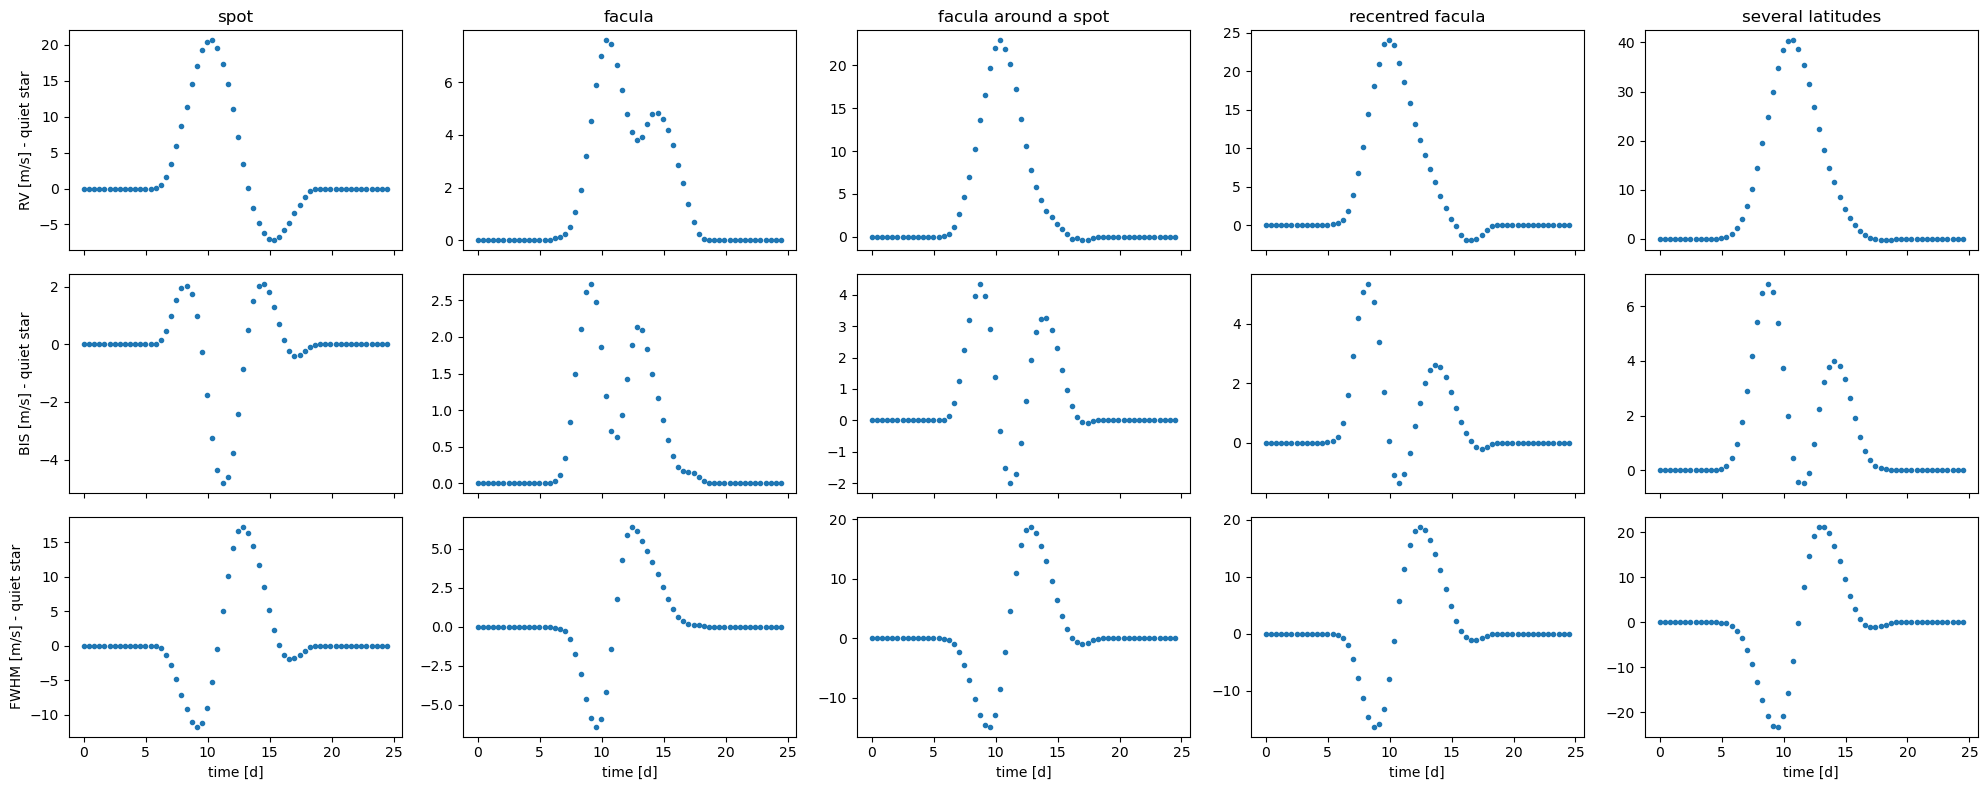

In [38]:
quantities = [('rv_var', 'RV [m/s]'), ('bis_var', 'BIS [m/s]'), ('fwhm_var', 'FWHM [m/s]')]
names = list(scenarios)
fig, axes = plt.subplots(3, len(names), figsize=(4 * len(names), 8), sharex=True)
for j, name in enumerate(names):
    ss = ccf_runs[name]
    for i, (attr, label) in enumerate(quantities):
        values = getattr(ss, attr)
        axes[i, j].plot(ss.obs_times, values - values[0], '.')       # difference with the quiet star (first epoch)
        if j == 0:
            axes[i, j].set_ylabel(label + ' - quiet star')
    axes[0, j].set_title(name)
    axes[-1, j].set_xlabel('time [d]')
plt.tight_layout()
plt.show()

**Going further.**

* To add the convective blueshift, set `convective_blueshift` above (it multiplies the Dumusque bisector) or give another bisector `f(mu) -> p(ccf)` to `built_grid(bisector=...)`, for instance one that depends on μ.
* `CCF_grid(..., mu_ratio=None)` computes the CCF of every ring from its own spectrum (it then needs the spectra at several μ).
* With `instrument='HARPS-N'`, `blaze_function=(wavelengths, blaze)` and `instrumental_efficiency`, the CCF is computed order by order after degrading the spectrum to the resolution of the instrument.